In [306]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [307]:
general_data = pd.read_csv("../input_data/general_data.csv")
employee_survey = pd.read_csv("../input_data/employee_survey_data.csv")
manager_survey = pd.read_csv("../input_data/manager_survey_data.csv")
in_time_data = pd.read_csv("../input_data/in_time.csv")
out_time_data = pd.read_csv("../input_data/out_time.csv")

In [308]:
general_data.head(5)

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeID,Gender,...,NumCompaniesWorked,Over18,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,1,Female,...,1.0,Y,11,8,0,1.0,6,1,0,0
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,1,2,Female,...,0.0,Y,23,8,1,6.0,3,5,1,4
2,32,No,Travel_Frequently,Research & Development,17,4,Other,1,3,Male,...,1.0,Y,15,8,3,5.0,2,5,0,3
3,38,No,Non-Travel,Research & Development,2,5,Life Sciences,1,4,Male,...,3.0,Y,11,8,3,13.0,5,8,7,5
4,32,No,Travel_Rarely,Research & Development,10,1,Medical,1,5,Male,...,4.0,Y,12,8,2,9.0,2,6,0,4


In [309]:
general_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4410 non-null   int64  
 1   Attrition                4410 non-null   object 
 2   BusinessTravel           4410 non-null   object 
 3   Department               4410 non-null   object 
 4   DistanceFromHome         4410 non-null   int64  
 5   Education                4410 non-null   int64  
 6   EducationField           4410 non-null   object 
 7   EmployeeCount            4410 non-null   int64  
 8   EmployeeID               4410 non-null   int64  
 9   Gender                   4410 non-null   object 
 10  JobLevel                 4410 non-null   int64  
 11  JobRole                  4410 non-null   object 
 12  MaritalStatus            4410 non-null   object 
 13  MonthlyIncome            4410 non-null   int64  
 14  NumCompaniesWorked      

In [310]:
general_data.isna().sum()

Age                         0
Attrition                   0
BusinessTravel              0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeID                  0
Gender                      0
JobLevel                    0
JobRole                     0
MaritalStatus               0
MonthlyIncome               0
NumCompaniesWorked         19
Over18                      0
PercentSalaryHike           0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           9
TrainingTimesLastYear       0
YearsAtCompany              0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64

In [311]:
manager_survey.isna().sum()
manager_survey.info()
manager_survey.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   EmployeeID         4410 non-null   int64
 1   JobInvolvement     4410 non-null   int64
 2   PerformanceRating  4410 non-null   int64
dtypes: int64(3)
memory usage: 103.5 KB


,EmployeeID,JobInvolvement,PerformanceRating
0,1,3,3
1,2,2,4
2,3,3,3
3,4,2,3
4,5,3,3


In [312]:
employee_survey.isna().sum()
employee_survey.info()
employee_survey.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   EmployeeID               4410 non-null   int64  
 1   EnvironmentSatisfaction  4385 non-null   float64
 2   JobSatisfaction          4390 non-null   float64
 3   WorkLifeBalance          4372 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 137.9 KB


,EmployeeID,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance
0,1,3.0,4.0,2.0
1,2,3.0,2.0,4.0
2,3,2.0,2.0,1.0
3,4,4.0,4.0,3.0
4,5,4.0,1.0,3.0


In [313]:
manager_survey.isna().sum()
manager_survey.info()
manager_survey.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   EmployeeID         4410 non-null   int64
 1   JobInvolvement     4410 non-null   int64
 2   PerformanceRating  4410 non-null   int64
dtypes: int64(3)
memory usage: 103.5 KB


,EmployeeID,JobInvolvement,PerformanceRating
0,1,3,3
1,2,2,4
2,3,3,3
3,4,2,3
4,5,3,3


In [314]:
employee_data_joined = general_data.join(employee_survey.set_index('EmployeeID'), on='EmployeeID', how='left')
employee_data_joined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4410 non-null   int64  
 1   Attrition                4410 non-null   object 
 2   BusinessTravel           4410 non-null   object 
 3   Department               4410 non-null   object 
 4   DistanceFromHome         4410 non-null   int64  
 5   Education                4410 non-null   int64  
 6   EducationField           4410 non-null   object 
 7   EmployeeCount            4410 non-null   int64  
 8   EmployeeID               4410 non-null   int64  
 9   Gender                   4410 non-null   object 
 10  JobLevel                 4410 non-null   int64  
 11  JobRole                  4410 non-null   object 
 12  MaritalStatus            4410 non-null   object 
 13  MonthlyIncome            4410 non-null   int64  
 14  NumCompaniesWorked      

In [315]:
employee_data_joined = employee_data_joined.join(manager_survey.set_index('EmployeeID'),on='EmployeeID', how='left')

In [316]:
employee_data_joined = employee_data_joined.set_index('EmployeeID')

In [317]:
employee_data_joined['BusinessTravel'].value_counts()

Travel_Rarely        3129
Travel_Frequently     831
Non-Travel            450
Name: BusinessTravel, dtype: int64

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'DistanceFromHome'}>,
        <Axes: title={'center': 'Education'}>,
        <Axes: title={'center': 'EmployeeCount'}>],
       [<Axes: title={'center': 'JobLevel'}>,
        <Axes: title={'center': 'MonthlyIncome'}>,
        <Axes: title={'center': 'NumCompaniesWorked'}>,
        <Axes: title={'center': 'PercentSalaryHike'}>],
       [<Axes: title={'center': 'StandardHours'}>,
        <Axes: title={'center': 'StockOptionLevel'}>,
        <Axes: title={'center': 'TotalWorkingYears'}>,
        <Axes: title={'center': 'TrainingTimesLastYear'}>],
       [<Axes: title={'center': 'YearsAtCompany'}>,
        <Axes: title={'center': 'YearsSinceLastPromotion'}>,
        <Axes: title={'center': 'YearsWithCurrManager'}>,
        <Axes: title={'center': 'EnvironmentSatisfaction'}>],
       [<Axes: title={'center': 'JobSatisfaction'}>,
        <Axes: title={'center': 'WorkLifeBalance'}>,
        <Axes: title={'center': 'JobIn

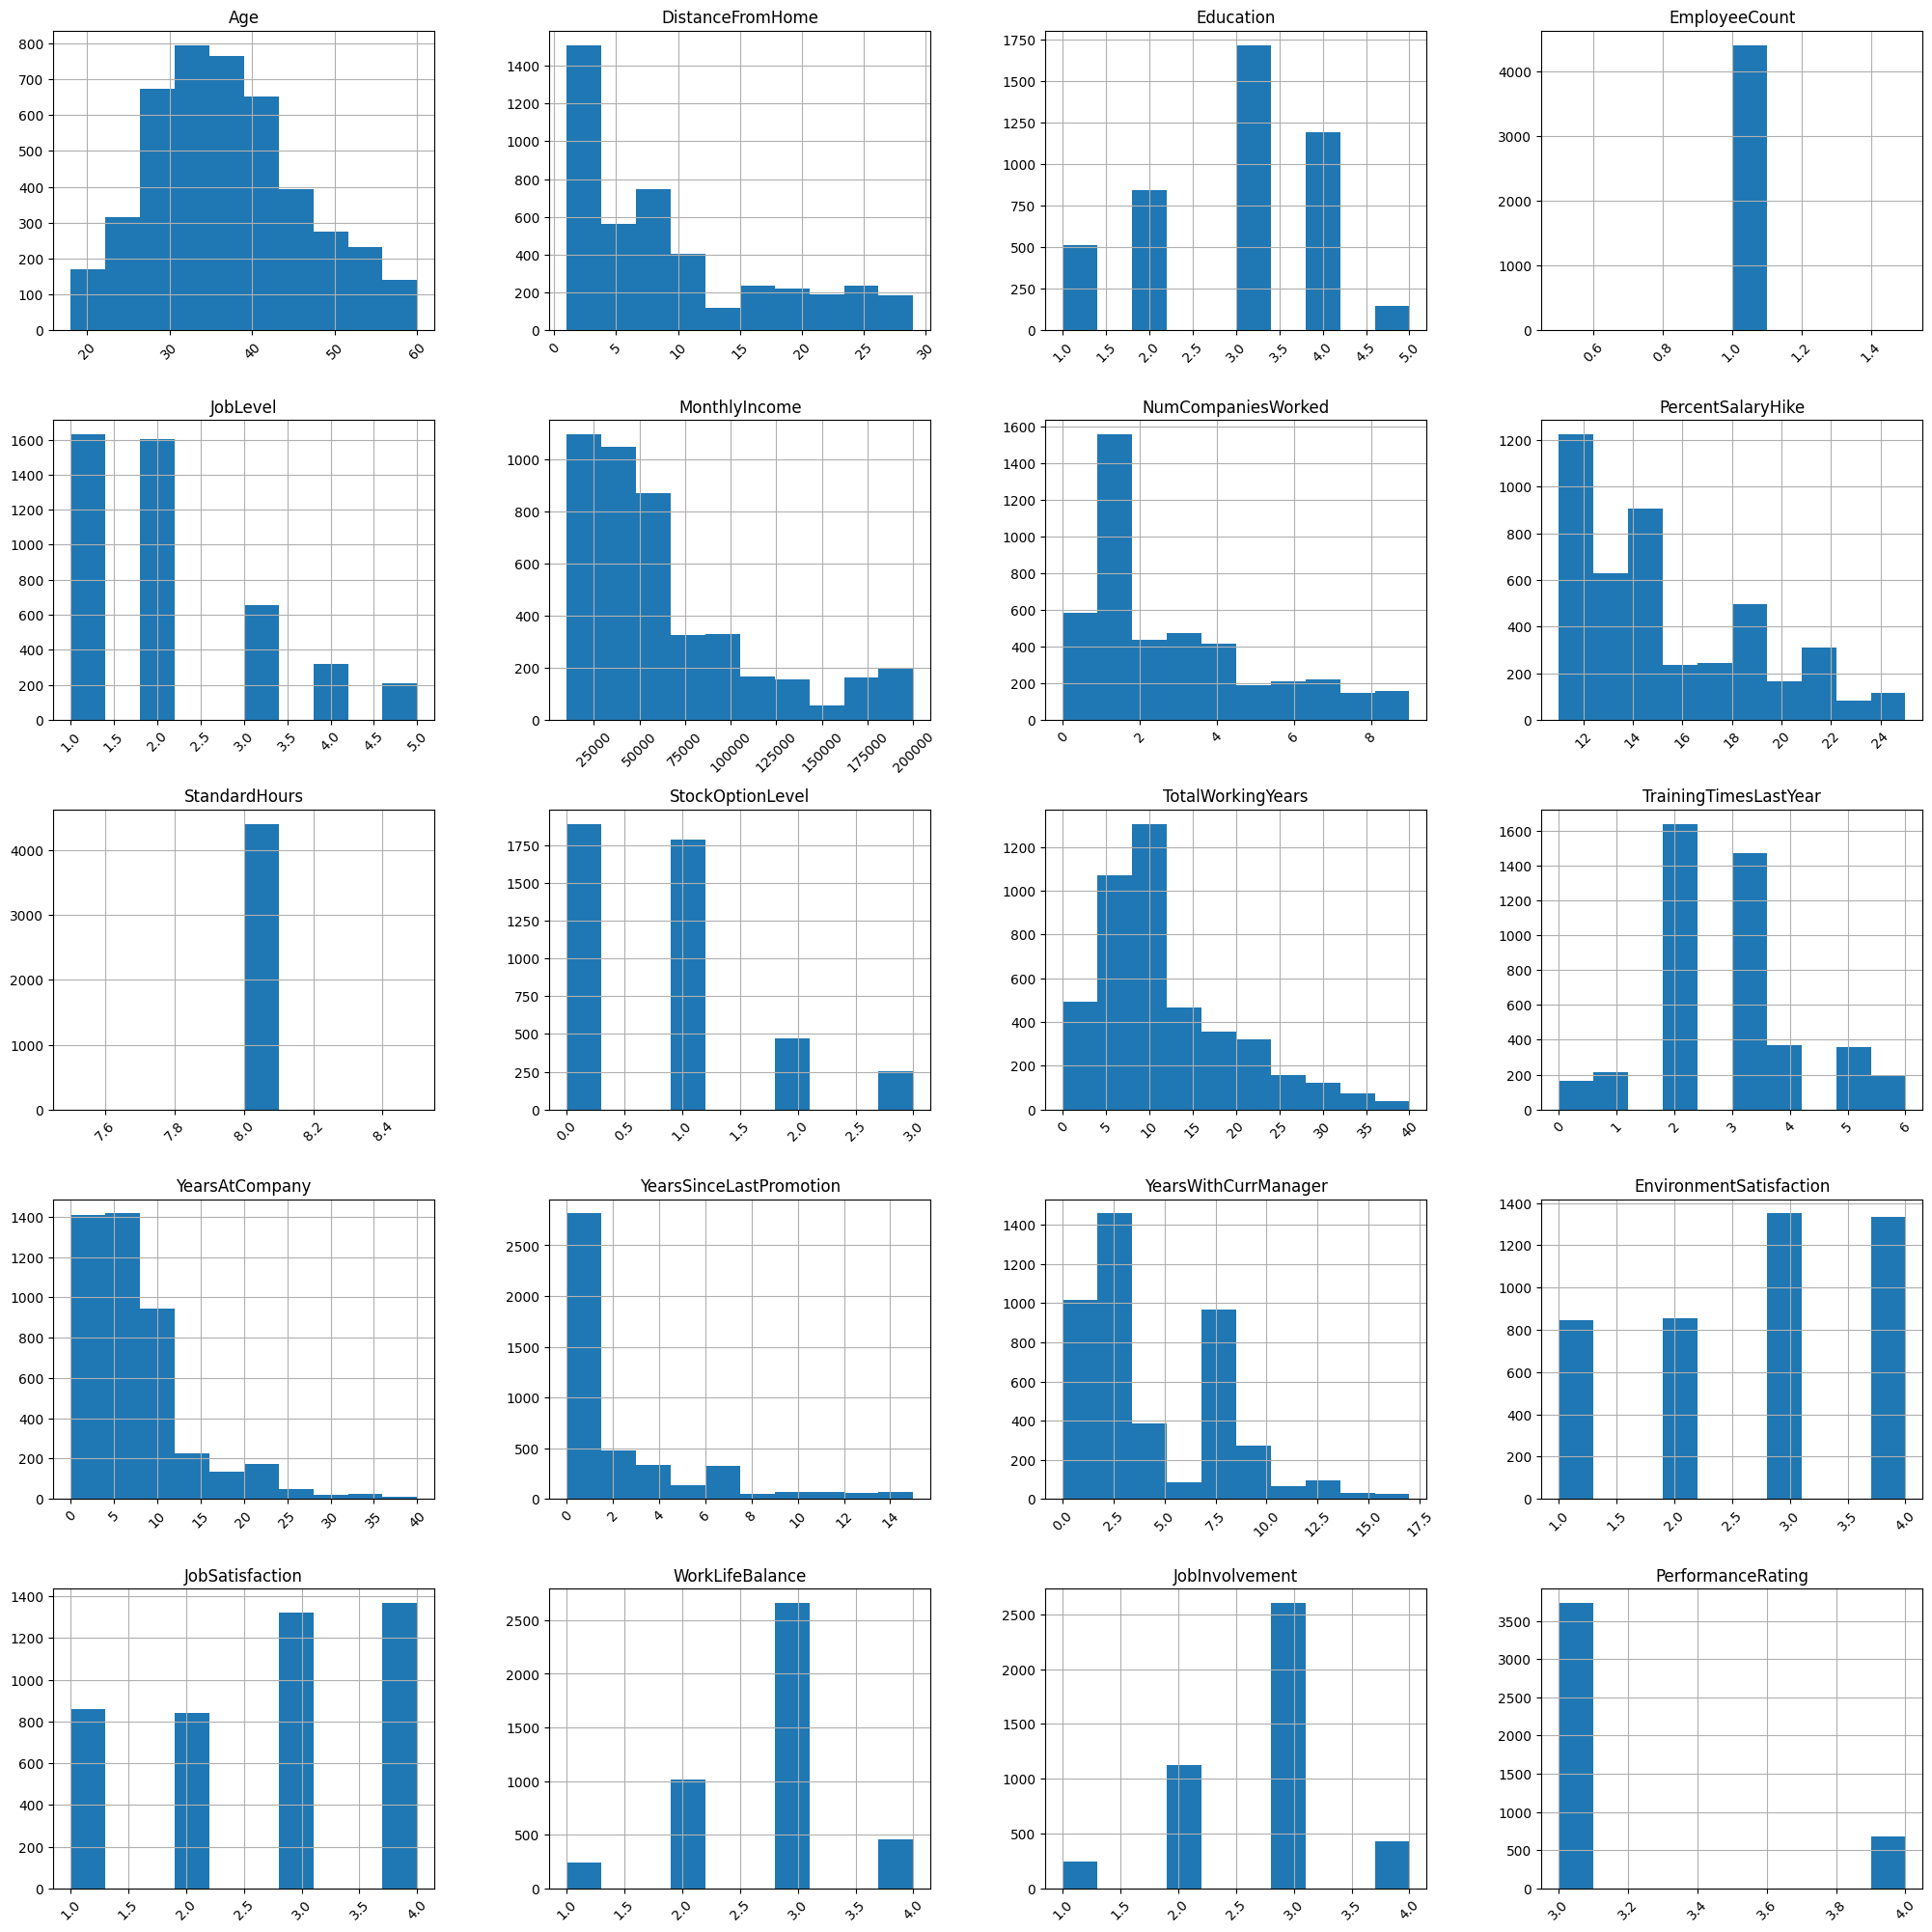

In [318]:
employee_data_joined.hist(figsize=(25,25), xrot=45)

Exploring further each feature to see if we find any trend of pattern between features and attrition.

In [319]:
attrition_counts = employee_data_joined['Attrition'].value_counts()
total_count = attrition_counts.sum()
attrition_rate = attrition_counts['Yes'] / total_count * 100
print(f"Attrition Rate is: {attrition_rate:.2f}%")

Attrition Rate is: 16.12%


In [320]:
employee_data_joined['Attrition'] = employee_data_joined['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

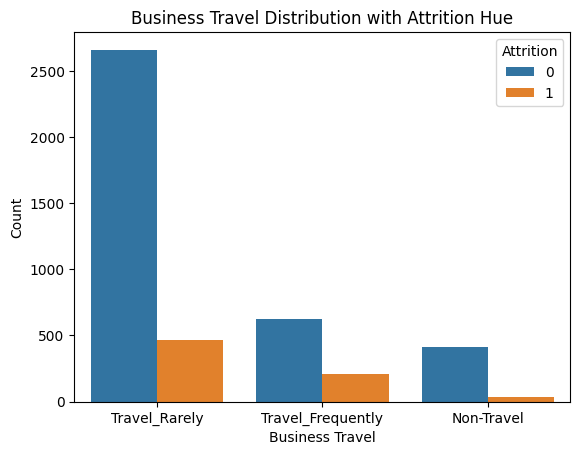

In [321]:
sns.countplot(x='BusinessTravel', hue='Attrition', data=employee_data_joined)
plt.xlabel('Business Travel')
plt.ylabel('Count')
plt.title('Business Travel Distribution with Attrition Hue')
plt.legend(title='Attrition')
plt.show()

In [322]:
employee_data_joined.groupby('BusinessTravel')['Attrition'].mean() * 100

BusinessTravel
Non-Travel            8.000000
Travel_Frequently    24.909747
Travel_Rarely        14.956855
Name: Attrition, dtype: float64

Traveling Frequently has a higher rate of Attrition than the Attrition rate of the company, in contrast with 8% for non-travel employees.

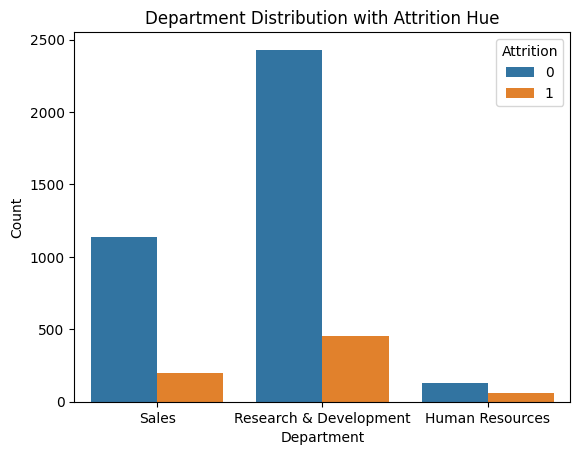

In [323]:
sns.countplot(x='Department', hue='Attrition', data=employee_data_joined)
plt.xlabel('Department')
plt.ylabel('Count')
plt.title('Department Distribution with Attrition Hue')
plt.legend(title='Attrition')
plt.show()

In [324]:
employee_data_joined.groupby('Department')['Attrition'].mean() * 100

Department
Human Resources           30.158730
Research & Development    15.712799
Sales                     15.022422
Name: Attrition, dtype: float64

Human Resources has a higher rate of 30.16% of attrition rate, it is higher than the company Attrition rate.

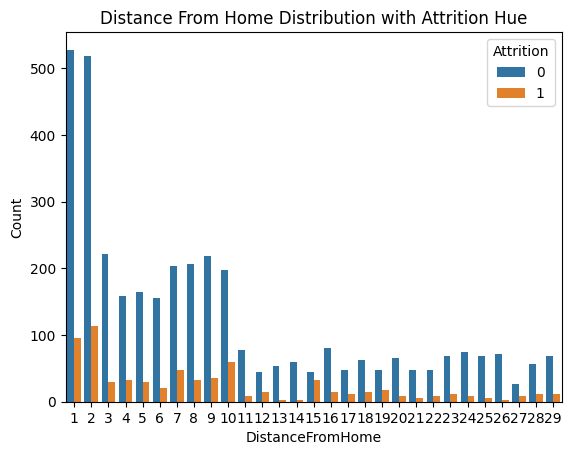

In [325]:
sns.countplot(x='DistanceFromHome', hue='Attrition', data=employee_data_joined)
plt.xlabel('DistanceFromHome')
plt.ylabel('Count')
plt.title('Distance From Home Distribution with Attrition Hue')
plt.legend(title='Attrition')
plt.show()

In [326]:
(employee_data_joined.groupby('DistanceFromHome')['Attrition'].mean() * 100).sort_values(ascending=False)

DistanceFromHome
15    42.307692
19    27.272727
27    25.000000
12    25.000000
10    23.255814
17    20.000000
18    19.230769
7     19.047619
2     18.009479
28    17.391304
4     17.187500
22    15.789474
16    15.625000
1     15.384615
5     15.384615
23    14.814815
29    14.814815
9     14.117647
8     13.750000
20    12.000000
3     11.904762
6     11.864407
21    11.111111
24    10.714286
11    10.344828
25     8.000000
13     5.263158
14     4.761905
26     4.000000
Name: Attrition, dtype: float64

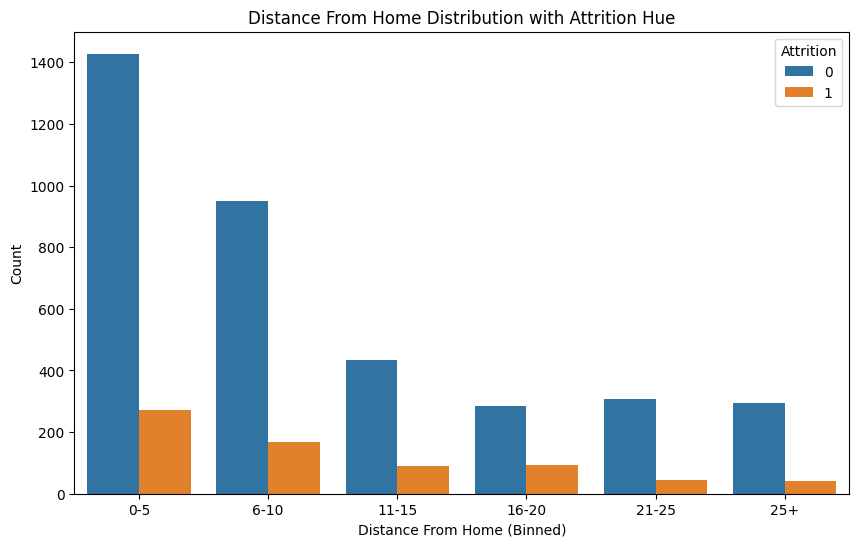

In [327]:
bins = [0, 5, 10, 15, 20, 25, float('inf')]
labels = ['0-5', '6-10', '11-15', '16-20', '21-25', '25+']
employee_data_joined['DistanceFromHomeBinned'] = pd.cut(employee_data_joined['DistanceFromHome'], bins=bins, labels=labels, right=False)

plt.figure(figsize=(10, 6))
ax = sns.countplot(x='DistanceFromHomeBinned', hue='Attrition', data=employee_data_joined)
plt.xlabel('Distance From Home (Binned)')
plt.ylabel('Count')
plt.title('Distance From Home Distribution with Attrition Hue')
plt.legend(title='Attrition')
plt.show()

In [328]:
employee_data_joined.groupby('DistanceFromHomeBinned')['Attrition'].mean() * 100

DistanceFromHomeBinned
0-5      16.049383
6-10     15.013405
11-15    17.142857
16-20    24.603175
21-25    12.820513
25+      12.500000
Name: Attrition, dtype: float64

Employees that lives between 16-20km from work, has a higher attrition rate (24.6%) than the average attrition rate. 

In [329]:
ordered_categorical_features = []

In [330]:
employee_data_joined['Education'].value_counts()

3    1716
4    1194
2     846
1     510
5     144
Name: Education, dtype: int64

In [331]:
ordered_categorical_features.append('Education')

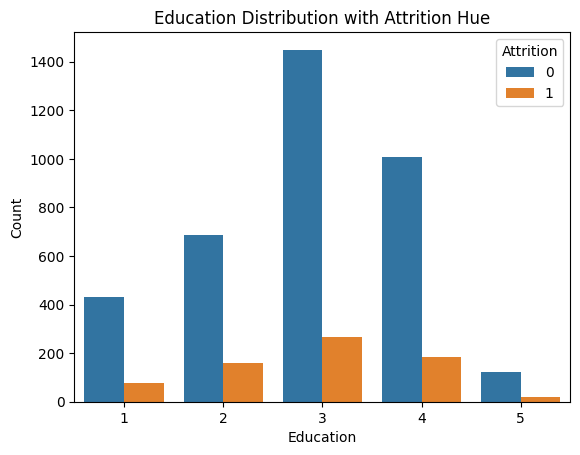

In [332]:
sns.countplot(x='Education', hue='Attrition', data=employee_data_joined)
plt.xlabel('Education')
plt.ylabel('Count')
plt.title('Education Distribution with Attrition Hue')
plt.legend(title='Attrition')
plt.show()

In [333]:
employee_data_joined.groupby('Education')['Attrition'].mean() * 100

Education
1    15.294118
2    18.794326
3    15.559441
4    15.577889
5    14.583333
Name: Attrition, dtype: float64

Employees with College degrees has a slightly higher attrition rate of 18.79%.

In [334]:
employee_data_joined['EducationField'].value_counts()

Life Sciences       1818
Medical             1392
Marketing            477
Technical Degree     396
Other                246
Human Resources       81
Name: EducationField, dtype: int64

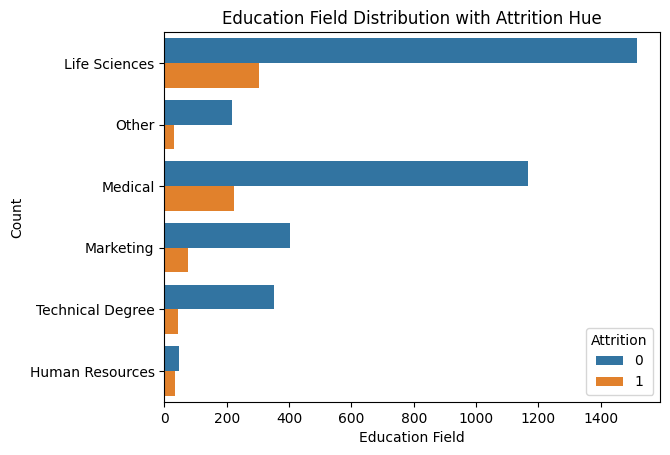

In [335]:
sns.countplot(y='EducationField', hue='Attrition', data=employee_data_joined)
plt.xlabel('Education Field')
plt.ylabel('Count')
plt.title('Education Field Distribution with Attrition Hue')
plt.legend(title='Attrition')
plt.show()

In [336]:
employee_data_joined.groupby('EducationField')['Attrition'].mean() * 100

EducationField
Human Resources     40.740741
Life Sciences       16.666667
Marketing           15.723270
Medical             16.163793
Other               12.195122
Technical Degree    11.363636
Name: Attrition, dtype: float64

Employees in Human Resources field has a higher attrition rate of 40.74%!

In [337]:
employee_data_joined['EmployeeCount'].value_counts()

1    4410
Name: EmployeeCount, dtype: int64

In [338]:
employee_data_joined['Gender'].value_counts()

Male      2646
Female    1764
Name: Gender, dtype: int64

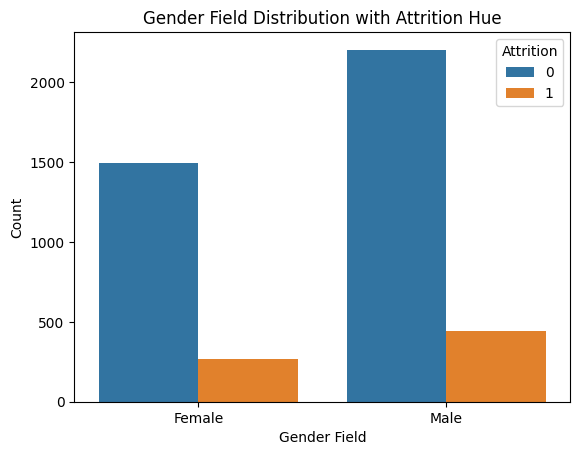

In [339]:
sns.countplot(x='Gender', hue='Attrition', data=employee_data_joined)
plt.xlabel('Gender Field')
plt.ylabel('Count')
plt.title('Gender Field Distribution with Attrition Hue')
plt.legend(title='Attrition')
plt.show()

In [340]:
employee_data_joined.groupby('Gender')['Attrition'].mean() * 100

Gender
Female    15.306122
Male      16.666667
Name: Attrition, dtype: float64

There is not much difference between genders in attrition rates. Male employees has a slitly higher attrition rate than females. 

In [341]:
employee_data_joined['JobLevel'].value_counts()

1    1629
2    1602
3     654
4     318
5     207
Name: JobLevel, dtype: int64

In [342]:
ordered_categorical_features.append('JobLevel')

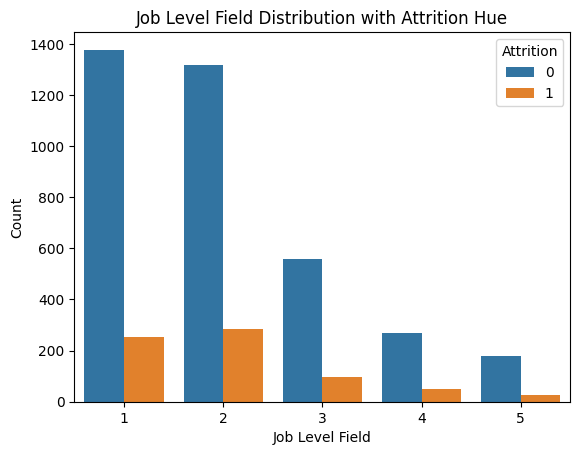

In [343]:
sns.countplot(x='JobLevel', hue='Attrition', data=employee_data_joined)
plt.xlabel('Job Level Field')
plt.ylabel('Count')
plt.title('Job Level Field Distribution with Attrition Hue')
plt.legend(title='Attrition')
plt.show()

In [344]:
employee_data_joined.groupby('JobLevel')['Attrition'].mean() * 100

JobLevel
1    15.469613
2    17.790262
3    14.678899
4    16.037736
5    13.043478
Name: Attrition, dtype: float64

Level 2 jobs has a slitly higher attrition rate 17.79%.

In [345]:
employee_data_joined['JobRole'].value_counts()

Sales Executive              978
Research Scientist           876
Laboratory Technician        777
Manufacturing Director       435
Healthcare Representative    393
Manager                      306
Sales Representative         249
Research Director            240
Human Resources              156
Name: JobRole, dtype: int64

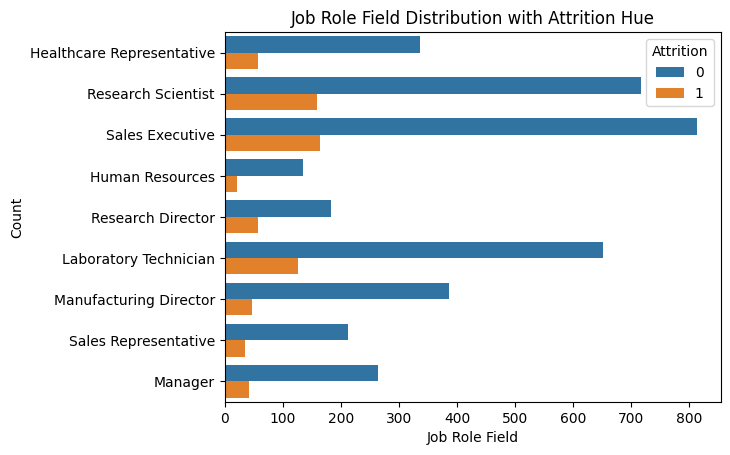

In [346]:
sns.countplot(y='JobRole', hue='Attrition', data=employee_data_joined)
plt.xlabel('Job Role Field')
plt.ylabel('Count')
plt.title('Job Role Field Distribution with Attrition Hue')
plt.legend(title='Attrition')
plt.show()

In [347]:
employee_data_joined.groupby('JobRole')['Attrition'].mean() * 100

JobRole
Healthcare Representative    14.503817
Human Resources              13.461538
Laboratory Technician        16.216216
Manager                      13.725490
Manufacturing Director       11.034483
Research Director            23.750000
Research Scientist           18.150685
Sales Executive              16.871166
Sales Representative         14.457831
Name: Attrition, dtype: float64

Research Dorector and Research Scientist have a higher rate (23.75% and 18.15% respectively) of attrition than the company's attrtion rate. 

In [348]:
employee_data_joined['MaritalStatus'].value_counts()

Married     2019
Single      1410
Divorced     981
Name: MaritalStatus, dtype: int64

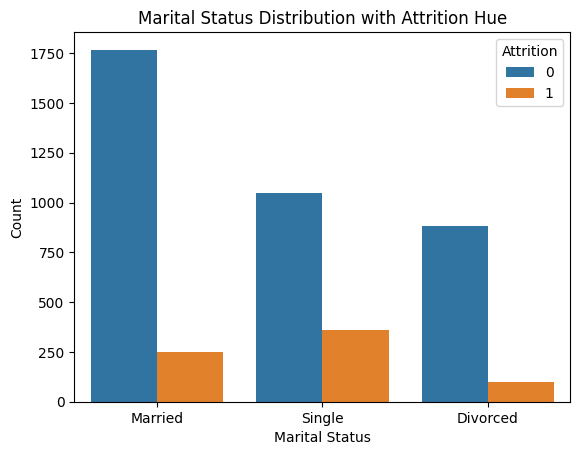

In [349]:
sns.countplot(x='MaritalStatus', hue='Attrition', data=employee_data_joined)
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.title('Marital Status Distribution with Attrition Hue')
plt.legend(title='Attrition')
plt.show()

In [350]:
employee_data_joined.groupby('MaritalStatus')['Attrition'].mean() * 100

MaritalStatus
Divorced    10.091743
Married     12.481426
Single      25.531915
Name: Attrition, dtype: float64

Being Single employee has a higher attrition rate 25.53% than Divorced or Married employees.

In [351]:
employee_data_joined['MonthlyIncome'].value_counts()

23420     12
61420      9
27410      9
26100      9
23800      9
          ..
120610     3
56740      3
96130      3
69290      3
54680      3
Name: MonthlyIncome, Length: 1349, dtype: int64

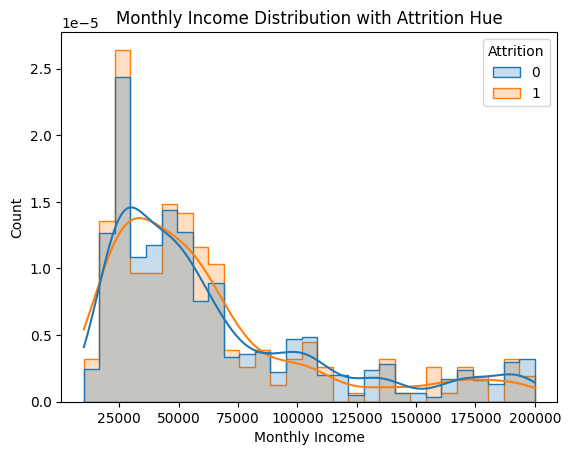

In [352]:
sns.histplot(data=employee_data_joined, x='MonthlyIncome', hue='Attrition', kde=True, element="step", stat="density", common_norm=False)
plt.xlabel('Monthly Income')
plt.ylabel('Count')
plt.title('Monthly Income Distribution with Attrition Hue')
plt.show()

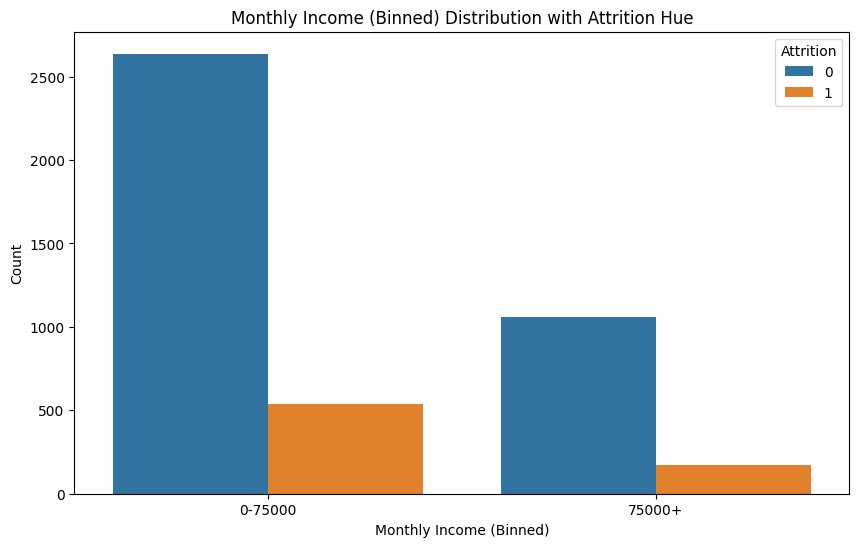

In [353]:
bins = [0, 75000, float('inf')]
labels = ['0-75000', '75000+']
employee_data_joined['MonthlyIncomeBinned'] = pd.cut(employee_data_joined['MonthlyIncome'], bins=bins, labels=labels, right=False)

plt.figure(figsize=(10, 6))
ax = sns.countplot(x='MonthlyIncomeBinned', hue='Attrition', data=employee_data_joined)
plt.xlabel('Monthly Income (Binned)')
plt.ylabel('Count')
plt.title('Monthly Income (Binned) Distribution with Attrition Hue')
plt.legend(title='Attrition')
plt.show()

In [354]:
employee_data_joined.groupby('MonthlyIncomeBinned')['Attrition'].mean() * 100

MonthlyIncomeBinned
0-75000    16.997167
75000+     13.868613
Name: Attrition, dtype: float64

The chart and calculations on top suggest that employees earning less than 75k have higher attrition rate (~17%) than average attrition rate of the company. 

In [355]:
employee_data_joined['NumCompaniesWorked'].value_counts()

1.0    1558
0.0     586
3.0     474
2.0     438
4.0     415
7.0     222
6.0     208
5.0     187
9.0     156
8.0     147
Name: NumCompaniesWorked, dtype: int64

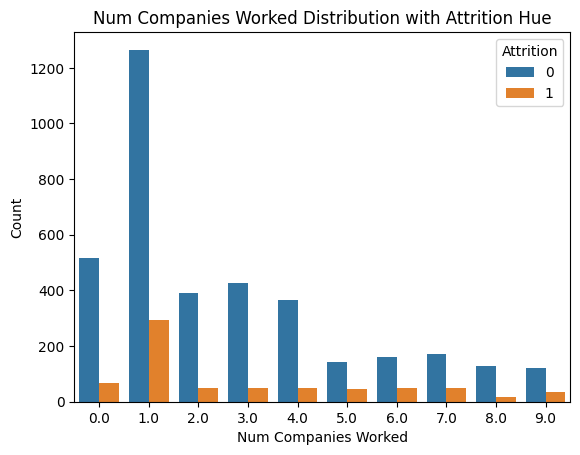

In [356]:
sns.countplot(x='NumCompaniesWorked', hue='Attrition', data=employee_data_joined)
plt.xlabel('Num Companies Worked')
plt.ylabel('Count')
plt.title('Num Companies Worked Distribution with Attrition Hue')
plt.legend(title='Attrition')
plt.show()

In [357]:
employee_data_joined.groupby('NumCompaniesWorked')['Attrition'].mean() * 100

NumCompaniesWorked
0.0    11.774744
1.0    18.806162
2.0    10.958904
3.0    10.126582
4.0    12.048193
5.0    24.598930
6.0    23.076923
7.0    22.972973
8.0    12.244898
9.0    23.076923
Name: Attrition, dtype: float64

In [358]:
employee_data_joined['Over18'].value_counts()   

Y    4410
Name: Over18, dtype: int64

In [359]:
employee_data_joined['PercentSalaryHike'].value_counts()

11    630
13    627
14    603
12    594
15    303
18    267
17    246
16    234
19    228
22    168
20    165
21    144
23     84
24     63
25     54
Name: PercentSalaryHike, dtype: int64

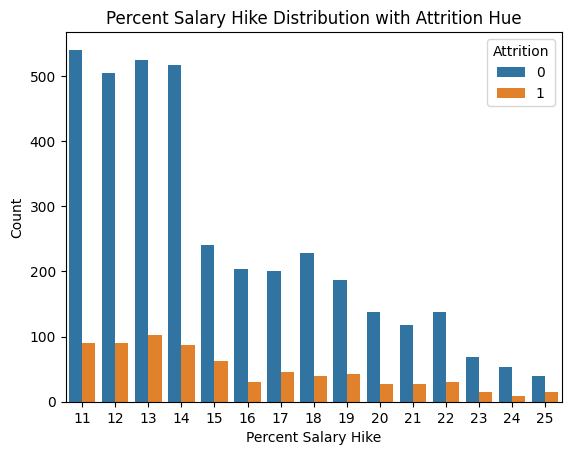

In [360]:
sns.countplot(x='PercentSalaryHike', hue='Attrition', data=employee_data_joined)
plt.xlabel('Percent Salary Hike')
plt.ylabel('Count')
plt.title('Percent Salary Hike Distribution with Attrition Hue')
plt.legend(title='Attrition')
plt.show()

In [361]:
employee_data_joined.groupby('PercentSalaryHike')['Attrition'].mean() * 100

PercentSalaryHike
11    14.285714
12    15.151515
13    16.267943
14    14.427861
15    20.792079
16    12.820513
17    18.292683
18    14.606742
19    18.421053
20    16.363636
21    18.750000
22    17.857143
23    17.857143
24    14.285714
25    27.777778
Name: Attrition, dtype: float64

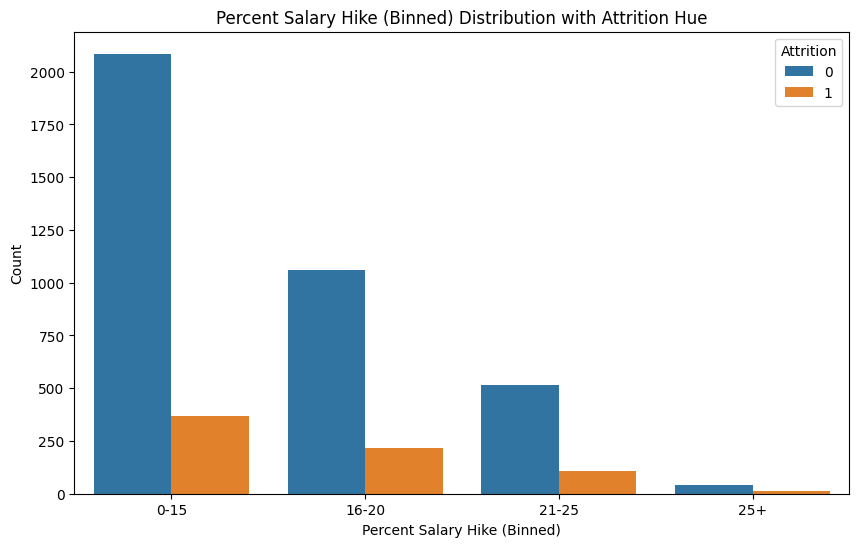

In [362]:
bins = [0, 15, 20, 25, float('inf')]
labels = ['0-15', '16-20', '21-25', '25+']
employee_data_joined['PercentSalaryHikeBinned'] = pd.cut(employee_data_joined['PercentSalaryHike'], bins=bins, labels=labels, right=False)

plt.figure(figsize=(10, 6))
ax = sns.countplot(x='PercentSalaryHikeBinned', hue='Attrition', data=employee_data_joined)
plt.xlabel('Percent Salary Hike (Binned)')
plt.ylabel('Count')
plt.title('Percent Salary Hike (Binned) Distribution with Attrition Hue')
plt.legend(title='Attrition')
plt.show()

In [363]:
employee_data_joined.groupby('PercentSalaryHikeBinned')['Attrition'].mean() * 100

PercentSalaryHikeBinned
0-15     15.036675
16-20    17.136150
21-25    17.307692
25+      27.777778
Name: Attrition, dtype: float64

Employees with a 25+ porcent salary hike has 27.27% of attrition rate.

In [364]:
employee_data_joined['StandardHours'].value_counts()

8    4410
Name: StandardHours, dtype: int64

In [365]:
employee_data_joined['StockOptionLevel'].value_counts()

0    1893
1    1788
2     474
3     255
Name: StockOptionLevel, dtype: int64

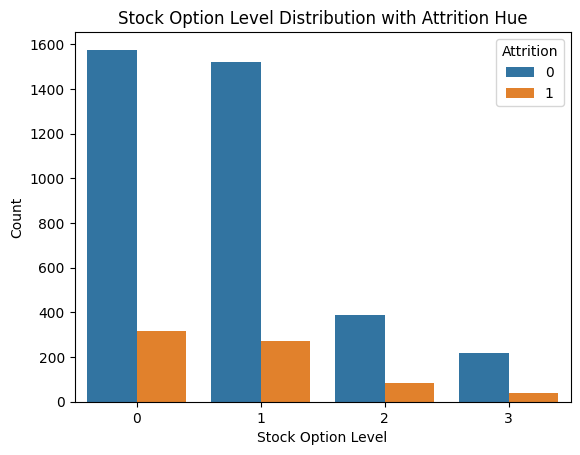

In [366]:
sns.countplot(x='StockOptionLevel', hue='Attrition', data=employee_data_joined)
plt.xlabel('Stock Option Level')
plt.ylabel('Count')
plt.title('Stock Option Level Distribution with Attrition Hue')
plt.legend(title='Attrition')
plt.show()

In [367]:
ordered_categorical_features.append('StockOptionLevel')

In [368]:
employee_data_joined['TotalWorkingYears'].value_counts()

10.0    605
6.0     375
8.0     307
9.0     287
5.0     264
7.0     243
1.0     242
4.0     189
12.0    144
3.0     126
15.0    120
16.0    111
13.0    108
11.0    106
21.0    102
17.0     99
14.0     93
2.0      93
20.0     89
18.0     81
23.0     66
19.0     66
22.0     62
24.0     54
25.0     42
26.0     42
28.0     42
0.0      33
29.0     30
31.0     27
32.0     27
27.0     21
30.0     21
33.0     21
36.0     18
34.0     15
37.0     12
35.0      9
40.0      6
38.0      3
Name: TotalWorkingYears, dtype: int64

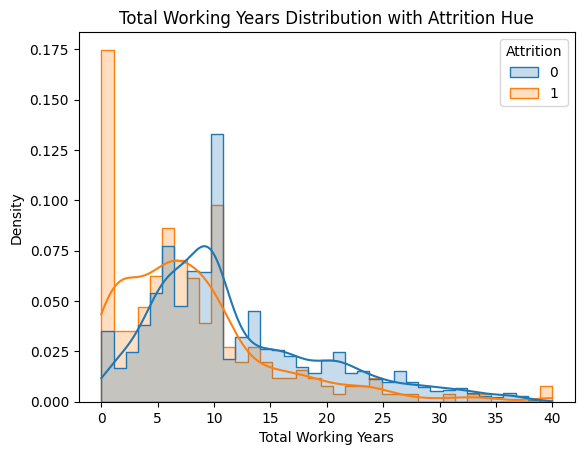

In [369]:
sns.histplot(data=employee_data_joined, x='TotalWorkingYears', hue='Attrition', kde=True, element="step", stat="density", common_norm=False)
plt.xlabel('Total Working Years')
plt.ylabel('Density')
plt.title('Total Working Years Distribution with Attrition Hue')
plt.show()

In [370]:
employee_data_joined.groupby('TotalWorkingYears')['Attrition'].mean() * 100

TotalWorkingYears
0.0      45.454545
1.0      49.173554
2.0      29.032258
3.0      21.428571
4.0      19.047619
5.0      18.181818
6.0      17.600000
7.0      22.222222
8.0      15.309446
9.0      10.452962
10.0     12.396694
11.0     19.811321
12.0     10.416667
13.0      8.333333
14.0     12.903226
15.0     12.500000
16.0      8.108108
17.0      9.090909
18.0     14.814815
19.0     13.636364
20.0      6.741573
21.0      2.941176
22.0      9.677419
23.0      9.090909
24.0     16.666667
25.0      7.142857
26.0      7.142857
27.0      0.000000
28.0      7.142857
29.0      0.000000
30.0      0.000000
31.0     11.111111
32.0      0.000000
33.0     14.285714
34.0     20.000000
35.0      0.000000
36.0      0.000000
37.0      0.000000
38.0      0.000000
40.0    100.000000
Name: Attrition, dtype: float64

From the total number of working years, we can see that retirement is a factor for attrition rates, we can observe as well that attrition rate is lower after 20+ workinfg years. While the first 7 years of working indicates higher attrition rate, with the highest in the first two years of working with 45.45% and 49.17% respectively.

In [371]:
employee_data_joined['TrainingTimesLastYear'].value_counts()

2    1641
3    1473
4     369
5     357
1     213
6     195
0     162
Name: TrainingTimesLastYear, dtype: int64

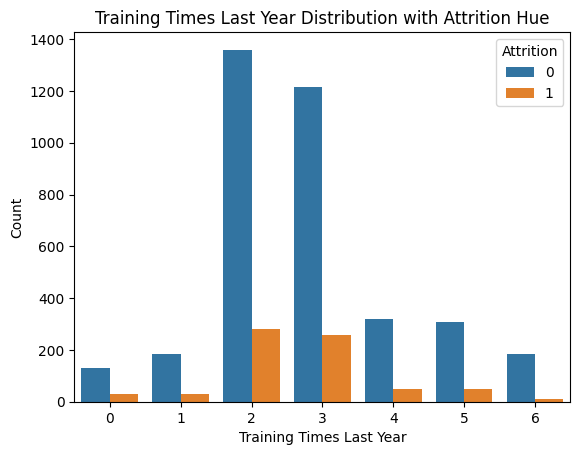

In [372]:
sns.countplot(x='TrainingTimesLastYear', hue='Attrition', data=employee_data_joined)
plt.xlabel('Training Times Last Year')
plt.ylabel('Count')
plt.title('Training Times Last Year Distribution with Attrition Hue')
plt.legend(title='Attrition')
plt.show()

In [373]:
employee_data_joined.groupby('TrainingTimesLastYear')['Attrition'].mean() * 100

TrainingTimesLastYear
0    18.518519
1    14.084507
2    17.184644
3    17.515275
4    13.008130
5    14.285714
6     6.153846
Name: Attrition, dtype: float64

In [374]:
employee_data_joined['YearsAtCompany'].value_counts()

5     588
1     513
3     384
2     381
10    360
4     330
7     270
9     246
8     240
6     228
0     132
11     96
20     81
13     72
15     60
14     54
22     45
12     42
21     42
18     39
16     36
19     33
17     27
24     18
33     15
26     12
25     12
31      9
32      9
29      6
27      6
36      6
23      6
34      3
30      3
37      3
40      3
Name: YearsAtCompany, dtype: int64

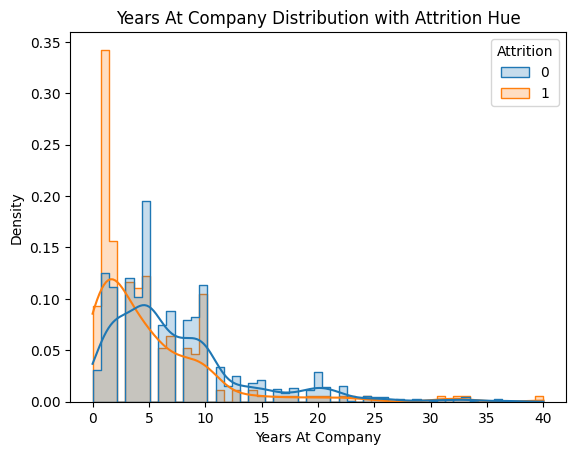

In [375]:
sns.histplot(data=employee_data_joined, x='YearsAtCompany', hue='Attrition', kde=True, element="step", stat="density", common_norm=False)
plt.xlabel('Years At Company')
plt.ylabel('Density')
plt.title('Years At Company Distribution with Attrition Hue')
plt.show()

In [376]:
employee_data_joined.groupby('YearsAtCompany')['Attrition'].mean() * 100

YearsAtCompany
0      36.363636
1      34.502924
2      21.259843
3      15.625000
4      17.272727
5      10.714286
6      11.842105
7      12.222222
8      11.250000
9       9.756098
10     15.000000
11      6.250000
12      0.000000
13      8.333333
14     11.111111
15      5.000000
16      8.333333
17     11.111111
18      7.692308
19      9.090909
20      3.703704
21      7.142857
22      6.666667
23     50.000000
24     16.666667
25      0.000000
26      0.000000
27      0.000000
29      0.000000
30      0.000000
31     33.333333
32     33.333333
33     20.000000
34      0.000000
36      0.000000
37      0.000000
40    100.000000
Name: Attrition, dtype: float64

We can see the same pattern than in the working years distribution. The first three years of a employee in the company could be the most important to determine attrition rates. 

In [377]:
employee_data_joined['YearsSinceLastPromotion'].value_counts()

0     1743
1     1071
2      477
7      228
4      183
3      156
5      135
6       96
11      72
8       54
9       51
15      39
13      30
12      30
14      27
10      18
Name: YearsSinceLastPromotion, dtype: int64

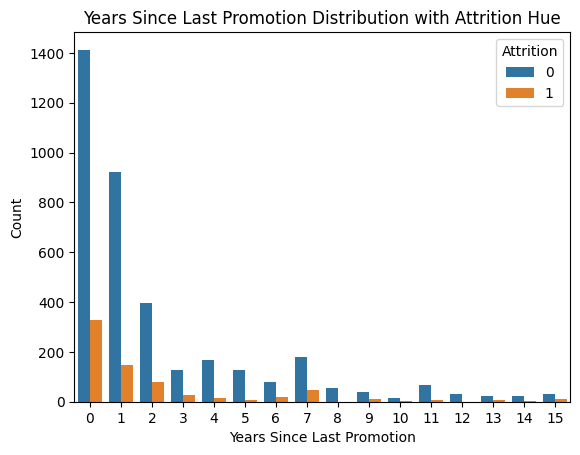

In [378]:
sns.countplot(x='YearsSinceLastPromotion', hue='Attrition', data=employee_data_joined)
plt.xlabel('Years Since Last Promotion')
plt.ylabel('Count')
plt.title('Years Since Last Promotion Distribution with Attrition Hue')
plt.legend(title='Attrition')
plt.show()

In [379]:
employee_data_joined.groupby('YearsSinceLastPromotion')['Attrition'].mean() * 100

YearsSinceLastPromotion
0     18.932874
1     13.725490
2     16.981132
3     17.307692
4      8.196721
5      4.444444
6     18.750000
7     21.052632
8      0.000000
9     23.529412
10    16.666667
11     8.333333
12     0.000000
13    20.000000
14    11.111111
15    23.076923
Name: Attrition, dtype: float64

In [380]:
employee_data_joined['YearsWithCurrManager'].value_counts()

2     1032
0      789
7      648
3      426
8      321
4      294
1      228
9      192
5       93
6       87
10      81
11      66
12      54
13      42
17      21
15      15
14      15
16       6
Name: YearsWithCurrManager, dtype: int64

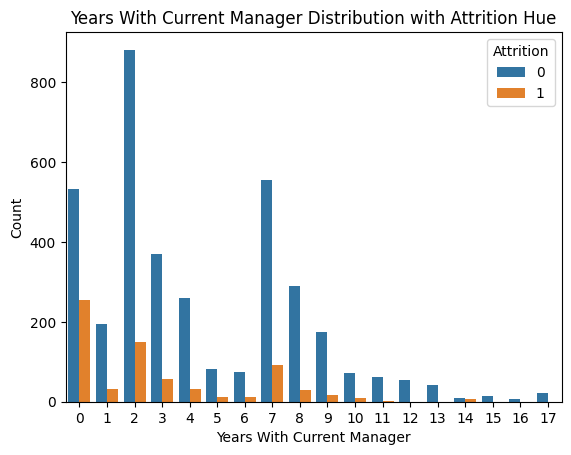

In [381]:
sns.countplot(x='YearsWithCurrManager', hue='Attrition', data=employee_data_joined)
plt.xlabel('Years With Current Manager')
plt.ylabel('Count')
plt.title('Years With Current Manager Distribution with Attrition Hue')
plt.legend(title='Attrition')
plt.show()

In [382]:
employee_data_joined.groupby('YearsWithCurrManager')['Attrition'].mean() * 100

YearsWithCurrManager
0     32.319392
1     14.473684
2     14.534884
3     13.380282
4     11.224490
5     12.903226
6     13.793103
7     14.351852
8      9.345794
9      9.375000
10    11.111111
11     4.545455
12     0.000000
13     0.000000
14    40.000000
15     0.000000
16     0.000000
17     0.000000
Name: Attrition, dtype: float64

Changes in the management roles could affect in the employee such than the attrition rate is higher (32.32%) in the first year of manager change.

In [383]:
employee_data_joined['EnvironmentSatisfaction'].value_counts()

3.0    1350
4.0    1334
2.0     856
1.0     845
Name: EnvironmentSatisfaction, dtype: int64

In [384]:
employee_data_joined['JobSatisfaction'].value_counts()

4.0    1367
3.0    1323
1.0     860
2.0     840
Name: JobSatisfaction, dtype: int64

In [385]:
employee_data_joined['WorkLifeBalance'].value_counts()

3.0    2660
2.0    1019
4.0     454
1.0     239
Name: WorkLifeBalance, dtype: int64

In [386]:
ordered_categorical_features.append('JobSatisfaction')
ordered_categorical_features.append('EnvironmentSatisfaction')
ordered_categorical_features.append('WorkLifeBalance')

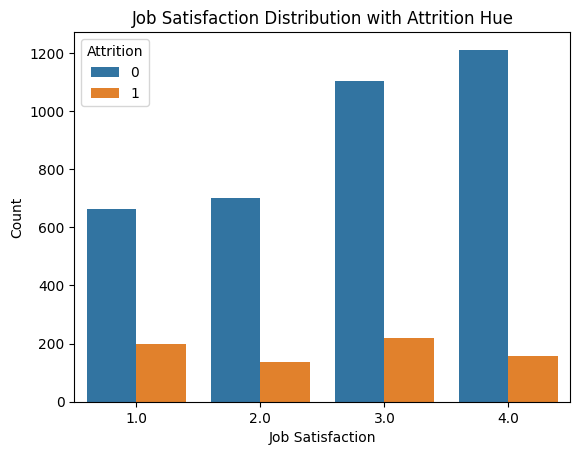

In [387]:
sns.countplot(x='JobSatisfaction', hue='Attrition', data=employee_data_joined)
plt.xlabel('Job Satisfaction')
plt.ylabel('Count')
plt.title('Job Satisfaction Distribution with Attrition Hue')
plt.legend(title='Attrition')
plt.show()

In [388]:
employee_data_joined.groupby('JobSatisfaction')['Attrition'].mean() * 100

JobSatisfaction
1.0    22.906977
2.0    16.428571
3.0    16.553288
4.0    11.411851
Name: Attrition, dtype: float64

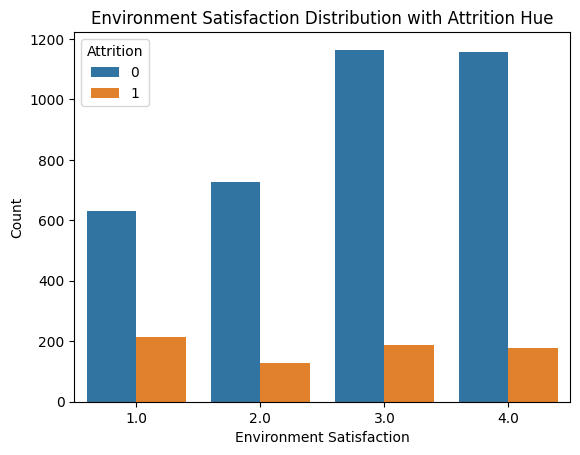

In [389]:
sns.countplot(x='EnvironmentSatisfaction', hue='Attrition', data=employee_data_joined)
plt.xlabel('Environment Satisfaction')
plt.ylabel('Count')
plt.title('Environment Satisfaction Distribution with Attrition Hue')
plt.legend(title='Attrition')
plt.show()

In [390]:
employee_data_joined.groupby('EnvironmentSatisfaction')['Attrition'].mean() * 100

EnvironmentSatisfaction
1.0    25.207101
2.0    14.953271
3.0    13.777778
4.0    13.418291
Name: Attrition, dtype: float64

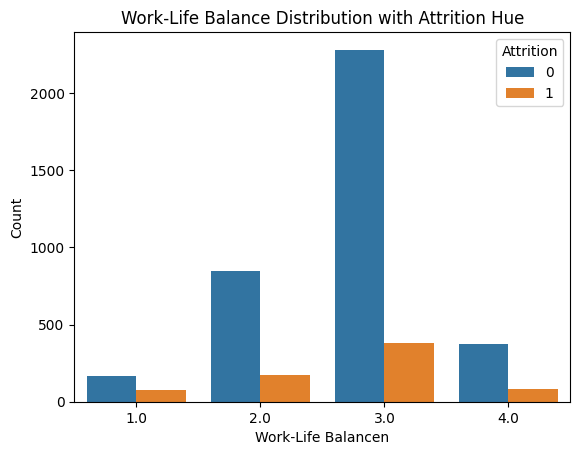

In [391]:
sns.countplot(x='WorkLifeBalance', hue='Attrition', data=employee_data_joined)
plt.xlabel('Work-Life Balancen')
plt.ylabel('Count')
plt.title('Work-Life Balance Distribution with Attrition Hue')
plt.legend(title='Attrition')
plt.show()

In [392]:
employee_data_joined.groupby('WorkLifeBalance')['Attrition'].mean() * 100

WorkLifeBalance
1.0    31.380753
2.0    16.781158
3.0    14.285714
4.0    17.841410
Name: Attrition, dtype: float64

Low rates in WorkLife Balance, Job Satisfaction and Environment Satisfaction have higher values in attrition rate. Work Balance seems to be an indicator of an employee attrition rate.

In [393]:
employee_data_joined['JobInvolvement'].value_counts()

3    2604
2    1125
4     432
1     249
Name: JobInvolvement, dtype: int64

In [394]:
ordered_categorical_features.append('JobInvolvement')

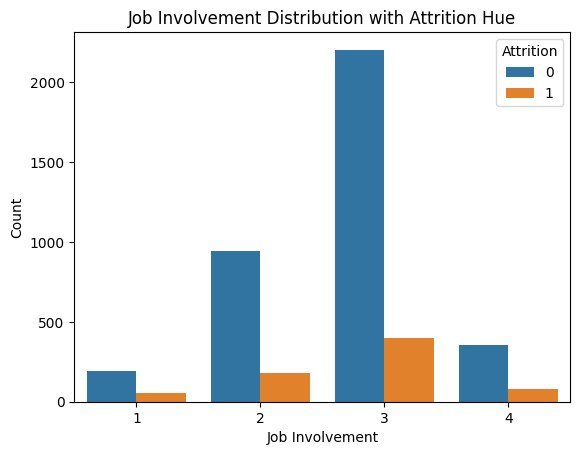

In [395]:
sns.countplot(x='JobInvolvement', hue='Attrition', data=employee_data_joined)
plt.xlabel('Job Involvement')
plt.ylabel('Count')
plt.title('Job Involvement Distribution with Attrition Hue')
plt.legend(title='Attrition')
plt.show()

In [396]:
employee_data_joined.groupby('JobInvolvement')['Attrition'].mean() * 100

JobInvolvement
1    21.686747
2    16.000000
3    15.322581
4    18.055556
Name: Attrition, dtype: float64

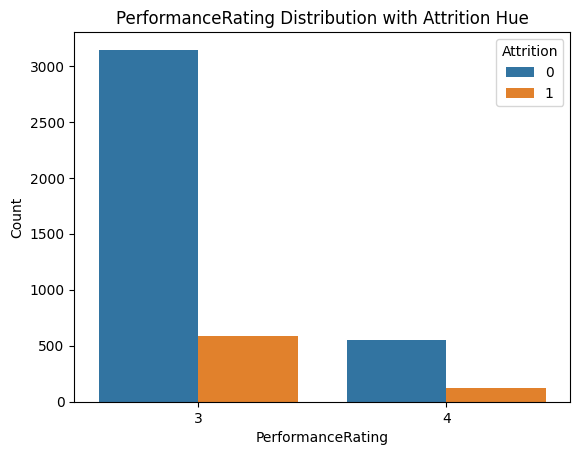

In [397]:
sns.countplot(x='PerformanceRating', hue='Attrition', data=employee_data_joined)
plt.xlabel('PerformanceRating')
plt.ylabel('Count')
plt.title('PerformanceRating Distribution with Attrition Hue')
plt.legend(title='Attrition')
plt.show()

In [398]:
employee_data_joined.groupby('PerformanceRating')['Attrition'].mean() * 100

PerformanceRating
3    15.755627
4    18.141593
Name: Attrition, dtype: float64

In [399]:
ordered_categorical_features.append('PerformanceRating')

From the top histograms of the employee data, we can see that StandardHours,EmployeeCount and Over18 would not contribute to the probability of attrition since there is only one value for all employees, so we will drop those features.

In [400]:
employee_data_joined.drop(columns=['Over18', 'EmployeeCount','StandardHours'], axis=1, inplace=True)

Analysis of timesheet data for employees

In [401]:
in_time_data.rename(columns={in_time_data.columns[0]: 'EmployeeID'}, inplace=True)
in_time_data.info()
in_time_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Columns: 262 entries, EmployeeID to 2015-12-31
dtypes: float64(12), int64(1), object(249)
memory usage: 8.8+ MB


,EmployeeID,2015-01-01,2015-01-02,2015-01-05,2015-01-06,2015-01-07,2015-01-08,2015-01-09,2015-01-12,2015-01-13,...,2015-12-18,2015-12-21,2015-12-22,2015-12-23,2015-12-24,2015-12-25,2015-12-28,2015-12-29,2015-12-30,2015-12-31
0,1,NaN,2015-01-02 09:43:45,2015-01-05 10:08:48,2015-01-06 09:54:26,2015-01-07 09:34:31,2015-01-08 09:51:09,2015-01-09 10:09:25,2015-01-12 09:42:53,2015-01-13 10:13:06,...,NaN,2015-12-21 09:55:29,2015-12-22 10:04:06,2015-12-23 10:14:27,2015-12-24 10:11:35,NaN,2015-12-28 10:13:41,2015-12-29 10:03:36,2015-12-30 09:54:12,2015-12-31 10:12:44
1,2,NaN,2015-01-02 10:15:44,2015-01-05 10:21:05,NaN,2015-01-07 09:45:17,2015-01-08 10:09:04,2015-01-09 09:43:26,2015-01-12 10:00:07,2015-01-13 10:43:29,...,2015-12-18 10:37:17,2015-12-21 09:49:02,2015-12-22 10:33:51,2015-12-23 10:12:10,NaN,NaN,2015-12-28 09:31:45,2015-12-29 09:55:49,2015-12-30 10:32:25,2015-12-31 09:27:20
2,3,NaN,2015-01-02 10:17:41,2015-01-05 09:50:50,2015-01-06 10:14:13,2015-01-07 09:47:27,2015-01-08 10:03:40,2015-01-09 10:05:49,2015-01-12 10:03:47,2015-01-13 10:21:26,...,2015-12-18 10:15:14,2015-12-21 10:10:28,2015-12-22 09:44:44,2015-12-23 10:15:54,2015-12-24 10:07:26,NaN,2015-12-28 09:42:05,2015-12-29 09:43:36,2015-12-30 09:34:05,2015-12-31 10:28:39
3,4,NaN,2015-01-02 10:05:06,2015-01-05 09:56:32,2015-01-06 10:11:07,2015-01-07 09:37:30,2015-01-08 10:02:08,2015-01-09 10:08:12,2015-01-12 10:13:42,2015-01-13 09:53:22,...,2015-12-18 10:17:38,2015-12-21 09:58:21,2015-12-22 10:04:25,2015-12-23 10:11:46,2015-12-24 09:43:15,NaN,2015-12-28 09:52:44,2015-12-29 09:33:16,2015-12-30 10:18:12,2015-12-31 10:01:15
4,5,NaN,2015-01-02 10:28:17,2015-01-05 09:49:58,2015-01-06 09:45:28,2015-01-07 09:49:37,2015-01-08 10:19:44,2015-01-09 10:00:50,2015-01-12 10:29:27,2015-01-13 09:59:32,...,2015-12-18 09:58:35,2015-12-21 10:03:41,2015-12-22 10:10:30,2015-12-23 10:13:36,2015-12-24 09:44:24,NaN,2015-12-28 10:05:15,2015-12-29 10:30:53,2015-12-30 09:18:21,2015-12-31 09:41:09


In [402]:
in_time_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Columns: 262 entries, EmployeeID to 2015-12-31
dtypes: float64(12), int64(1), object(249)
memory usage: 8.8+ MB


In [403]:
for col in in_time_data.columns[1:]:
    in_time_data[col] = pd.to_datetime(in_time_data[col], errors='coerce')

In [404]:
in_time_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Columns: 262 entries, EmployeeID to 2015-12-31
dtypes: datetime64[ns](261), int64(1)
memory usage: 8.8 MB


In [405]:
in_time_data_melted = in_time_data.melt(id_vars=['EmployeeID'], var_name='date', value_name='entry_time')
in_time_data_melted.head(5000)

,EmployeeID,date,entry_time
0,1,2015-01-01,NaT
1,2,2015-01-01,NaT
2,3,2015-01-01,NaT
3,4,2015-01-01,NaT
4,5,2015-01-01,NaT
...,...,...,...
4995,586,2015-01-02,2015-01-02 09:48:50
4996,587,2015-01-02,2015-01-02 09:34:51
4997,588,2015-01-02,2015-01-02 09:56:16
4998,589,2015-01-02,NaT


In [406]:
out_time_data.rename(columns={out_time_data.columns[0]: 'EmployeeID'}, inplace=True)
out_time_data.info()
out_time_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Columns: 262 entries, EmployeeID to 2015-12-31
dtypes: float64(12), int64(1), object(249)
memory usage: 8.8+ MB


,EmployeeID,2015-01-01,2015-01-02,2015-01-05,2015-01-06,2015-01-07,2015-01-08,2015-01-09,2015-01-12,2015-01-13,...,2015-12-18,2015-12-21,2015-12-22,2015-12-23,2015-12-24,2015-12-25,2015-12-28,2015-12-29,2015-12-30,2015-12-31
0,1,NaN,2015-01-02 16:56:15,2015-01-05 17:20:11,2015-01-06 17:19:05,2015-01-07 16:34:55,2015-01-08 17:08:32,2015-01-09 17:38:29,2015-01-12 16:58:39,2015-01-13 18:02:58,...,NaN,2015-12-21 17:15:50,2015-12-22 17:27:51,2015-12-23 16:44:44,2015-12-24 17:47:22,NaN,2015-12-28 18:00:07,2015-12-29 17:22:30,2015-12-30 17:40:56,2015-12-31 17:17:33
1,2,NaN,2015-01-02 18:22:17,2015-01-05 17:48:22,NaN,2015-01-07 17:09:06,2015-01-08 17:34:04,2015-01-09 16:52:29,2015-01-12 17:36:48,2015-01-13 18:00:13,...,2015-12-18 18:31:28,2015-12-21 17:34:16,2015-12-22 18:16:35,2015-12-23 17:38:18,NaN,NaN,2015-12-28 17:08:38,2015-12-29 17:54:46,2015-12-30 18:31:35,2015-12-31 17:40:58
2,3,NaN,2015-01-02 16:59:14,2015-01-05 17:06:46,2015-01-06 16:38:32,2015-01-07 16:33:21,2015-01-08 17:24:22,2015-01-09 16:57:30,2015-01-12 17:28:54,2015-01-13 17:21:25,...,2015-12-18 17:02:23,2015-12-21 17:20:17,2015-12-22 16:32:50,2015-12-23 16:59:43,2015-12-24 16:58:25,NaN,2015-12-28 16:43:31,2015-12-29 17:09:56,2015-12-30 17:06:25,2015-12-31 17:15:50
3,4,NaN,2015-01-02 17:25:24,2015-01-05 17:14:03,2015-01-06 17:07:42,2015-01-07 16:32:40,2015-01-08 16:53:11,2015-01-09 17:19:47,2015-01-12 17:13:37,2015-01-13 17:11:45,...,2015-12-18 17:55:23,2015-12-21 16:49:09,2015-12-22 17:24:00,2015-12-23 17:36:35,2015-12-24 16:48:21,NaN,2015-12-28 17:19:34,2015-12-29 16:58:16,2015-12-30 17:40:11,2015-12-31 17:09:14
4,5,NaN,2015-01-02 18:31:37,2015-01-05 17:49:15,2015-01-06 17:26:25,2015-01-07 17:37:59,2015-01-08 17:59:28,2015-01-09 17:44:08,2015-01-12 18:51:21,2015-01-13 18:14:58,...,2015-12-18 17:52:48,2015-12-21 17:43:35,2015-12-22 18:07:57,2015-12-23 18:00:49,2015-12-24 17:59:22,NaN,2015-12-28 17:44:59,2015-12-29 18:47:00,2015-12-30 17:15:33,2015-12-31 17:42:14


In [407]:
for col in out_time_data.columns[1:]:
    out_time_data[col] = pd.to_datetime(out_time_data[col], errors='coerce')

In [408]:
out_time_data_melted = out_time_data.melt(id_vars='EmployeeID',var_name='date', value_name='exit_time')

In [409]:
out_time_data_melted.head()

,EmployeeID,date,exit_time
0,1,2015-01-01,NaT
1,2,2015-01-01,NaT
2,3,2015-01-01,NaT
3,4,2015-01-01,NaT
4,5,2015-01-01,NaT


In [410]:
in_time_data_melted.set_index(['EmployeeID', 'date'], inplace=True)
out_time_data_melted.set_index(['EmployeeID', 'date'], inplace=True)

In [411]:
in_time_data_melted.info()
out_time_data_melted.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1151010 entries, (1, '2015-01-01') to (4410, '2015-12-31')
Data columns (total 1 columns):
 #   Column      Non-Null Count    Dtype         
---  ------      --------------    -----         
 0   entry_time  1041930 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 13.3+ MB
<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1151010 entries, (1, '2015-01-01') to (4410, '2015-12-31')
Data columns (total 1 columns):
 #   Column     Non-Null Count    Dtype         
---  ------     --------------    -----         
 0   exit_time  1041930 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 13.3+ MB


In [412]:
time_data_employees = in_time_data_melted.join(out_time_data_melted, how='left', lsuffix='_in', rsuffix='_out')
time_data_employees.head(5000)

,,entry_time,exit_time
EmployeeID,date,,
1,2015-01-01,NaT,NaT
2,2015-01-01,NaT,NaT
3,2015-01-01,NaT,NaT
4,2015-01-01,NaT,NaT
5,2015-01-01,NaT,NaT
...,...,...,...
586,2015-01-02,2015-01-02 09:48:50,2015-01-02 16:58:31
587,2015-01-02,2015-01-02 09:34:51,2015-01-02 17:26:18
588,2015-01-02,2015-01-02 09:56:16,2015-01-02 20:24:26


In [413]:
time_data_employees['entry_time']=time_data_employees['entry_time'].fillna(pd.Timestamp('00:00:00'))
time_data_employees['exit_time']=time_data_employees['exit_time'].fillna(pd.Timestamp('00:00:00'))
time_data_employees['entry_time'] = time_data_employees['entry_time'].dt.time
time_data_employees['exit_time'] = time_data_employees['exit_time'].dt.time

In [414]:
time_data_employees.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1151010 entries, (1, '2015-01-01') to (4410, '2015-12-31')
Data columns (total 2 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   entry_time  1151010 non-null  object
 1   exit_time   1151010 non-null  object
dtypes: object(2)
memory usage: 54.4+ MB


In [415]:
time_data_employees.head(5000)

,,entry_time,exit_time
EmployeeID,date,,
1,2015-01-01,00:00:00,00:00:00
2,2015-01-01,00:00:00,00:00:00
3,2015-01-01,00:00:00,00:00:00
4,2015-01-01,00:00:00,00:00:00
5,2015-01-01,00:00:00,00:00:00
...,...,...,...
586,2015-01-02,09:48:50,16:58:31
587,2015-01-02,09:34:51,17:26:18
588,2015-01-02,09:56:16,20:24:26


In [416]:
time_data_employees['daily_hours_worked']=(pd.to_timedelta(time_data_employees['exit_time'].astype(str)) - pd.to_timedelta(time_data_employees['entry_time'].astype(str))).dt.total_seconds()/3600

In [417]:
total_absents = time_data_employees['daily_hours_worked']==0

In [418]:
yearly_absents=time_data_employees[total_absents].groupby('EmployeeID')['daily_hours_worked'].count()
yearly_absents=yearly_absents.reset_index()
yearly_absents=yearly_absents.rename(columns={'daily_hours_worked': 'yearly_absents'})
yearly_absents['yearly_absents'].describe()

count    4410.000000
mean       24.734694
std         5.503779
min        13.000000
25%        20.000000
50%        25.000000
75%        29.000000
max        36.000000
Name: yearly_absents, dtype: float64

In [419]:
mean_daily_worked_hours = time_data_employees[~total_absents].groupby('EmployeeID')['daily_hours_worked'].mean()
mean_daily_worked_hours=mean_daily_worked_hours.reset_index()
mean_daily_worked_hours=mean_daily_worked_hours.rename(columns={'daily_hours_worked': 'mean_daily_worked_hours'})
mean_daily_worked_hours['mean_daily_worked_hours'].describe()

count    4410.000000
mean        7.700792
std         1.340218
min         5.950504
25%         6.673333
50%         7.406761
75%         8.368703
max        11.030960
Name: mean_daily_worked_hours, dtype: float64

In [420]:
overtime = time_data_employees['daily_hours_worked'] > 8

In [421]:
early_departures = (time_data_employees['daily_hours_worked'] < 8) & (time_data_employees['daily_hours_worked'] > 0)

In [422]:
laboral_days=time_data_employees[~total_absents].groupby('EmployeeID')['entry_time'].count()

In [423]:
early_departures_frequency = (time_data_employees[early_departures].groupby('EmployeeID')['daily_hours_worked'].count())/laboral_days
early_departures_frequency=early_departures_frequency.reset_index()
early_departures_frequency=early_departures_frequency.fillna(0)
early_departures_frequency=early_departures_frequency.rename(columns={0:'early_departures_frequency'})

In [424]:
overtime_frequency=(time_data_employees[overtime].groupby('EmployeeID')['daily_hours_worked'].count())/laboral_days
overtime_frequency=overtime_frequency.reset_index()
overtime_frequency=overtime_frequency.fillna(0)
overtime_frequency=overtime_frequency.rename(columns={0:'overtime_frequency'})



In [425]:
overtime_frequency.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   EmployeeID          4410 non-null   int64  
 1   overtime_frequency  4410 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 69.0 KB


In [426]:
employees_time_data = mean_daily_worked_hours.join(yearly_absents.set_index('EmployeeID'),on='EmployeeID',how='left')

In [427]:
employees_time_data = employees_time_data.join(overtime_frequency.set_index('EmployeeID'),on='EmployeeID',how='left')

In [428]:
employees_time_data = employees_time_data.join(early_departures_frequency.set_index('EmployeeID'),on='EmployeeID',how='left')

In [429]:
laboral_days = laboral_days.reset_index()
laboral_days.rename(columns={'entry_time':'number_workdays'})
employees_time_data = employees_time_data.join(laboral_days.set_index('EmployeeID'),on='EmployeeID',how='left')

In [430]:
average_entry_time = time_data_employees[~total_absents].groupby('EmployeeID')['entry_time'].apply(lambda x: np.mean([t.hour * 3600 + t.minute * 60 + t.second for t in x]) / 3600)
average_exit_time = time_data_employees[~total_absents].groupby('EmployeeID')['exit_time'].apply(lambda x: np.mean([t.hour * 3600 + t.minute * 60 + t.second for t in x]) / 3600)
average_entry_time = average_entry_time.reset_index()
average_exit_time = average_exit_time.reset_index()
average_entry_time = average_entry_time.rename(columns={'entry_time':'average_entry_time'})
average_exit_time = average_exit_time.rename(columns={'exit_time':'average_exit_time'})   

In [431]:
employees_time_data = employees_time_data.join(average_entry_time.set_index('EmployeeID'), on='EmployeeID', how='left')
employees_time_data = employees_time_data.join(average_exit_time.set_index('EmployeeID'), on='EmployeeID', how='left')

In [432]:
employees_time_data.head()

,EmployeeID,mean_daily_worked_hours,yearly_absents,overtime_frequency,early_departures_frequency,entry_time,average_entry_time,average_exit_time
0,1,7.373651,29,0.000000,1.000000,232,10.001422,17.375073
1,2,7.718969,25,0.177966,0.822034,236,9.988073,17.707042
2,3,7.013240,19,0.000000,1.000000,242,10.025061,17.038301
3,4,7.193678,26,0.000000,1.000000,235,9.981830,17.175508
4,5,8.006175,16,0.469388,0.530612,245,9.998493,18.004668


In [433]:
employees_time_data=employees_time_data.rename(columns={'entry_time':'working_days'})

In [434]:
employees_time_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   EmployeeID                  4410 non-null   int64  
 1   mean_daily_worked_hours     4410 non-null   float64
 2   yearly_absents              4410 non-null   int64  
 3   overtime_frequency          4410 non-null   float64
 4   early_departures_frequency  4410 non-null   float64
 5   working_days                4410 non-null   int64  
 6   average_entry_time          4410 non-null   float64
 7   average_exit_time           4410 non-null   float64
dtypes: float64(5), int64(3)
memory usage: 275.8 KB


In [435]:
employee_data_joined = employee_data_joined.join(employees_time_data.set_index('EmployeeID'), on='EmployeeID', how='left')

In [436]:
employee_data_joined.info()
employee_data_joined.head()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4410 entries, 1 to 4410
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   Age                         4410 non-null   int64   
 1   Attrition                   4410 non-null   int64   
 2   BusinessTravel              4410 non-null   object  
 3   Department                  4410 non-null   object  
 4   DistanceFromHome            4410 non-null   int64   
 5   Education                   4410 non-null   int64   
 6   EducationField              4410 non-null   object  
 7   Gender                      4410 non-null   object  
 8   JobLevel                    4410 non-null   int64   
 9   JobRole                     4410 non-null   object  
 10  MaritalStatus               4410 non-null   object  
 11  MonthlyIncome               4410 non-null   int64   
 12  NumCompaniesWorked          4391 non-null   float64 
 13  PercentSalaryHike 

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,Gender,JobLevel,JobRole,...,DistanceFromHomeBinned,MonthlyIncomeBinned,PercentSalaryHikeBinned,mean_daily_worked_hours,yearly_absents,overtime_frequency,early_departures_frequency,working_days,average_entry_time,average_exit_time
EmployeeID,,,,,,,,,,,,,,,,,,,,,
1,51,0,Travel_Rarely,Sales,6,2,Life Sciences,Female,1,Healthcare Representative,...,6-10,75000+,0-15,7.373651,29,0.000000,1.000000,232,10.001422,17.375073
2,31,1,Travel_Frequently,Research & Development,10,1,Life Sciences,Female,1,Research Scientist,...,11-15,0-75000,21-25,7.718969,25,0.177966,0.822034,236,9.988073,17.707042
3,32,0,Travel_Frequently,Research & Development,17,4,Other,Male,4,Sales Executive,...,16-20,75000+,16-20,7.013240,19,0.000000,1.000000,242,10.025061,17.038301
4,38,0,Non-Travel,Research & Development,2,5,Life Sciences,Male,3,Human Resources,...,0-5,75000+,0-15,7.193678,26,0.000000,1.000000,235,9.981830,17.175508
5,32,0,Travel_Rarely,Research & Development,10,1,Medical,Male,1,Sales Executive,...,11-15,0-75000,0-15,8.006175,16,0.469388,0.530612,245,9.998493,18.004668


In [437]:
employee_data_joined.isna().sum()

Age                            0
Attrition                      0
BusinessTravel                 0
Department                     0
DistanceFromHome               0
Education                      0
EducationField                 0
Gender                         0
JobLevel                       0
JobRole                        0
MaritalStatus                  0
MonthlyIncome                  0
NumCompaniesWorked            19
PercentSalaryHike              0
StockOptionLevel               0
TotalWorkingYears              9
TrainingTimesLastYear          0
YearsAtCompany                 0
YearsSinceLastPromotion        0
YearsWithCurrManager           0
EnvironmentSatisfaction       25
JobSatisfaction               20
WorkLifeBalance               38
JobInvolvement                 0
PerformanceRating              0
DistanceFromHomeBinned         0
MonthlyIncomeBinned            0
PercentSalaryHikeBinned        0
mean_daily_worked_hours        0
yearly_absents                 0
overtime_f

For now, lets drop all the na entries. We could infer values from the data such median rate for survey entries and median of num companies worked and total working years from people of the same age, same field.  

In [438]:
employee_data_joined.isnull().sum()/len(employee_data_joined)*100

Age                           0.000000
Attrition                     0.000000
BusinessTravel                0.000000
Department                    0.000000
DistanceFromHome              0.000000
Education                     0.000000
EducationField                0.000000
Gender                        0.000000
JobLevel                      0.000000
JobRole                       0.000000
MaritalStatus                 0.000000
MonthlyIncome                 0.000000
NumCompaniesWorked            0.430839
PercentSalaryHike             0.000000
StockOptionLevel              0.000000
TotalWorkingYears             0.204082
TrainingTimesLastYear         0.000000
YearsAtCompany                0.000000
YearsSinceLastPromotion       0.000000
YearsWithCurrManager          0.000000
EnvironmentSatisfaction       0.566893
JobSatisfaction               0.453515
WorkLifeBalance               0.861678
JobInvolvement                0.000000
PerformanceRating             0.000000
DistanceFromHomeBinned   

In [439]:
clean_employee_data = employee_data_joined.dropna()

/var/folders/p7/cshrl10s47n6p2hd0yjwjjsr0000gn/T/ipykernel_20916/4024533834.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(clean_employee_data.corr(), annot=True, fmt='.2f')


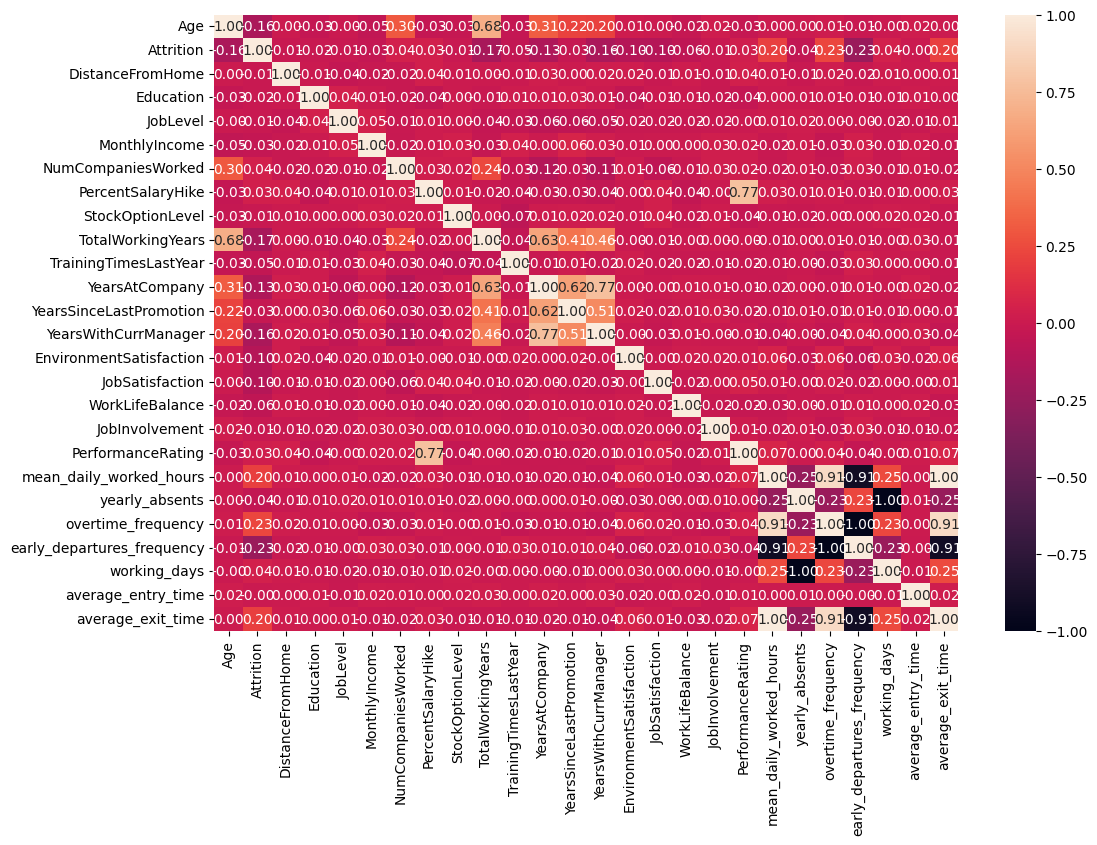

In [440]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(clean_employee_data.corr(), annot=True, fmt='.2f')
plt.show()

Since mean_daily_worked_hours is highly correlated with overtime_frequency, average_exit_time and early_departure_frequency, only it should be keep daily_worked_hours. 
Same with yearly_absent is highy correlated with working_days. We will keep yearly_absents.
To summarize, we keep mean_daily_worked_hours, yearly_absent and average_entry_time.

Knowing ordered categorical features, perhaps it could help to classification ML models.

In [441]:
ordered_categorical_features

['Education',
 'JobLevel',
 'StockOptionLevel',
 'JobSatisfaction',
 'EnvironmentSatisfaction',
 'WorkLifeBalance',
 'JobInvolvement',
 'PerformanceRating']

In [442]:
clean_employee_data.corr()

/var/folders/p7/cshrl10s47n6p2hd0yjwjjsr0000gn/T/ipykernel_20916/1504298063.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  clean_employee_data.corr()


,Age,Attrition,DistanceFromHome,Education,JobLevel,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,...,WorkLifeBalance,JobInvolvement,PerformanceRating,mean_daily_worked_hours,yearly_absents,overtime_frequency,early_departures_frequency,working_days,average_entry_time,average_exit_time
Age,1.000000,-0.155584,0.004621,-0.034452,-0.000781,-0.047256,0.303709,-0.034313,-0.030608,0.681213,...,-0.024756,0.021284,-0.025059,0.002990,0.004670,0.014471,-0.014478,-0.004670,0.021342,0.003278
Attrition,-0.155584,1.000000,-0.008314,-0.015237,-0.014587,-0.032629,0.043911,0.034425,-0.007971,-0.168637,...,-0.059817,-0.014705,0.026262,0.198126,-0.039770,0.230991,-0.230980,0.039770,-0.004741,0.198035
DistanceFromHome,0.004621,-0.008314,1.000000,-0.006369,-0.038576,-0.019798,-0.016336,0.035857,0.007376,0.004364,...,0.009345,-0.007972,0.035974,0.011001,-0.009963,0.016355,-0.016410,0.009963,0.003254,0.011043
Education,-0.034452,-0.015237,-0.006369,1.000000,0.043686,0.006381,-0.018156,-0.043592,0.000443,-0.008236,...,-0.005480,-0.020804,-0.035579,0.001664,0.007396,0.005109,-0.005135,-0.007396,0.011478,0.001819
JobLevel,-0.000781,-0.014587,-0.038576,0.043686,1.000000,0.045015,-0.008314,0.010119,0.002940,-0.035378,...,-0.022040,-0.015054,-0.001362,0.010142,0.016065,0.001200,-0.001198,-0.016065,-0.009133,0.010018
MonthlyIncome,-0.047256,-0.032629,-0.019798,0.006381,0.045015,1.000000,-0.020110,0.008684,0.034453,-0.029776,...,0.003702,0.028555,0.021096,-0.015124,0.008058,-0.033216,0.033251,-0.008058,0.019406,-0.014860
NumCompaniesWorked,0.303709,0.043911,-0.016336,-0.018156,-0.008314,-0.020110,1.000000,0.030201,0.015965,0.240077,...,-0.008871,0.026559,0.018649,-0.016200,0.009264,-0.026925,0.026937,-0.009264,0.009838,-0.016065
PercentSalaryHike,-0.034313,0.034425,0.035857,-0.043592,0.010119,0.008684,0.030201,1.000000,0.012531,-0.021199,...,-0.040252,-0.003603,0.773902,0.030593,0.006752,0.014555,-0.014601,-0.006752,0.004495,0.030650
StockOptionLevel,-0.030608,-0.007971,0.007376,0.000443,0.002940,0.034453,0.015965,0.012531,1.000000,0.000556,...,-0.022785,0.009347,-0.037390,-0.011621,-0.021536,-0.002981,0.002968,0.021536,0.015095,-0.011416
TotalWorkingYears,0.681213,-0.168637,0.004364,-0.008236,-0.035378,-0.029776,0.240077,-0.021199,0.000556,1.000000,...,-0.000430,0.004724,-0.002544,-0.009021,0.001227,0.005578,-0.005584,-0.001227,0.025039,-0.008682


In [443]:
feature_importance = pd.read_csv('../results/feature_importances.csv')
top_ten=feature_importance[:10]
feature_names = {
    'mean_daily_worked_hours': 'Mean Daily Worked Hours',
    'Age': 'Age',
    'TotalWorkingYears': 'Total Working Years',
    'MonthlyIncome_Squared': 'Monthly Income Squared',
    'YearsAtCompany': 'Years At Company',
    'DistanceFromHome_Squared': 'Distance From Home Squared',
    'YearsWithCurrManager': 'Years With Current Manager',
    'PercentSalaryHike': 'Percent Salary Hike',
    'NumCompaniesWorked': 'Number of Companies Worked',
    'average_entry_time': 'Average Entry Time'
}
top_ten['Feature']=top_ten['Feature'].apply(lambda x:feature_names[x])
top_features_df = top_ten

/var/folders/p7/cshrl10s47n6p2hd0yjwjjsr0000gn/T/ipykernel_20916/84664497.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_ten['Feature']=top_ten['Feature'].apply(lambda x:feature_names[x])


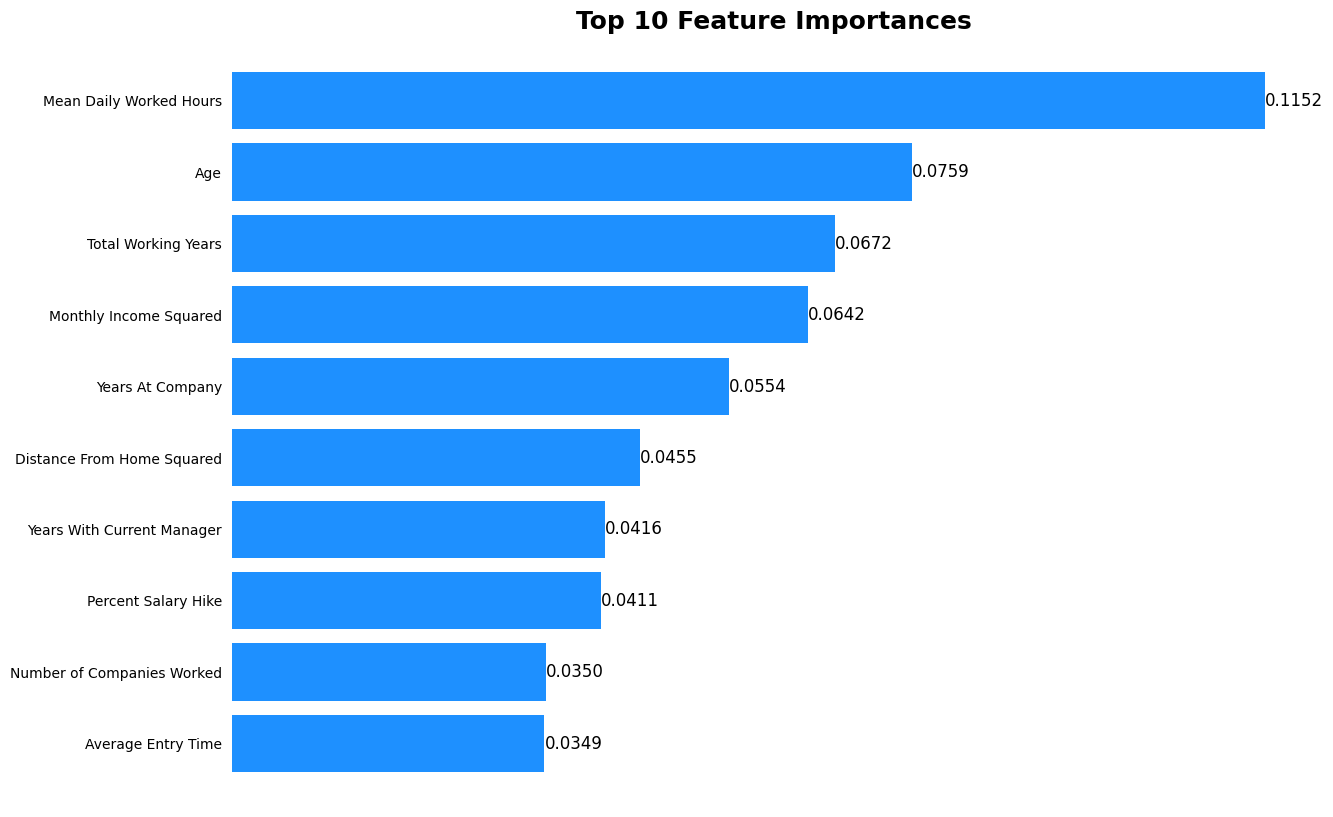

In [444]:

plt.figure(figsize=(14, 10))
bars = plt.barh(top_features_df['Feature'], top_features_df['Importance'], color='dodgerblue')

plt.xlabel('')
plt.ylabel('')

plt.title('Top 10 Feature Importances', fontsize=18, fontweight='bold')
plt.gca().invert_yaxis()

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)

plt.gca().tick_params(axis='y', which='both', left=False, right=False, labelleft=True)
plt.gca().tick_params(axis='x', which='both', top=False, bottom=False, labelbottom=False)

for bar in bars:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2, 
            f'{bar.get_width():.4f}', va='center', fontsize=12, color='black')
plt.show()

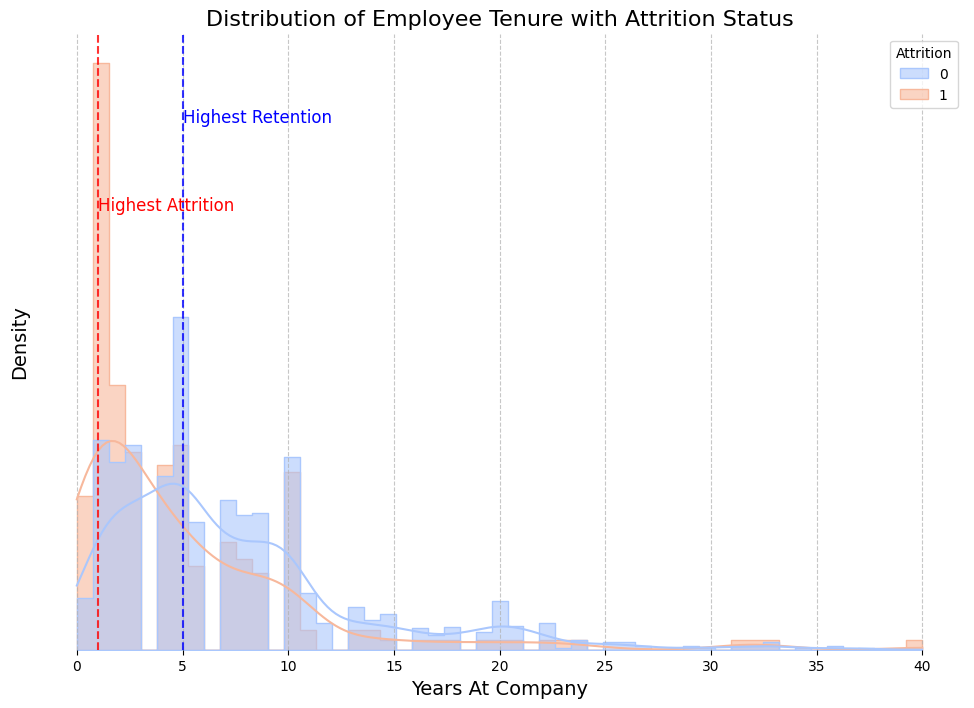

In [445]:
plt.figure(figsize=(12, 8))
sns.histplot(data=clean_employee_data, x='YearsAtCompany', hue='Attrition', kde=True, element="step", stat="density", common_norm=False, palette='coolwarm', alpha=0.6)

plt.xlabel('Years At Company', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.title('Distribution of Employee Tenure with Attrition Status', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().yaxis.set_ticks([])

max_attrition_years = clean_employee_data[clean_employee_data['Attrition'] == 1]['YearsAtCompany'].value_counts().idxmax()
max_no_attrition_years = clean_employee_data[clean_employee_data['Attrition'] == 0]['YearsAtCompany'].value_counts().idxmax()

plt.axvline(max_attrition_years, color='r', linestyle='--', alpha=0.8)
plt.axvline(max_no_attrition_years, color='b', linestyle='--', alpha=0.8)

plt.text(max_attrition_years, 0.25, 'Highest Attrition', horizontalalignment='left', fontsize=12, color='r')
plt.text(max_no_attrition_years, 0.3, 'Highest Retention', horizontalalignment='left', fontsize=12, color='b')

plt.show()


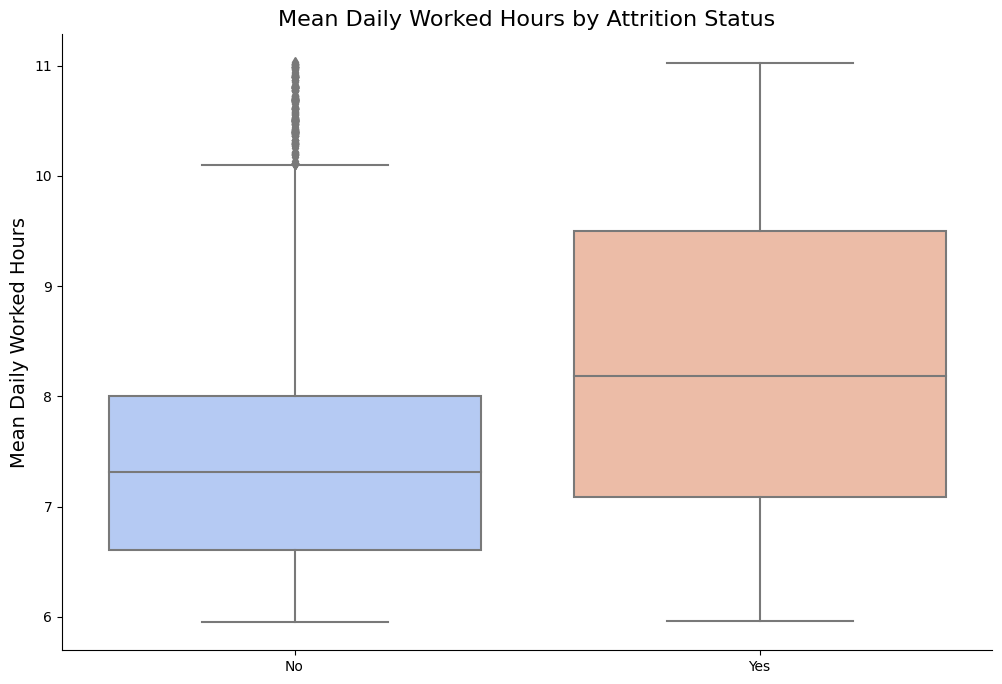

In [452]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=clean_employee_data, x='Attrition', y='mean_daily_worked_hours', palette='coolwarm')
plt.xlabel('')
plt.ylabel('Mean Daily Worked Hours', fontsize=14)
plt.title('Mean Daily Worked Hours by Attrition Status', fontsize=16)
plt.xticks([0, 1], ['No', 'Yes'])
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()